# CRMLS Sold Data Analysis

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Monthly Dataset Aggregation

In [2]:
# Get all CRMLSSold files
sold_data = glob.glob('**/CRMLSSold*.csv',recursive=True)

df_list = []
for file in sold_data:
    df = pd.read_csv(file, encoding='ISO-8859-1',low_memory=True)
    print(f"{file}: {len(df)}")
    df_list.append(df)
sold_df = pd.concat(df_list, ignore_index=True)

print(f'Rows after aggregation: {len(sold_df)}')

# Filter to residential
print(f"Rows before Residential Filter: {len(sold_df)}")
sold_df = sold_df[sold_df['PropertyType'] == "Residential"]
print(f"Rows after Residential Filter: {len(sold_df)}")

# Save to csv 
# sold_df.to_csv('AggSold.csv', index=False)

raw\CRMLSSold202401.csv: 17976
raw\CRMLSSold202402.csv: 19925
raw\CRMLSSold202403.csv: 23276
raw\CRMLSSold202404.csv: 24640
raw\CRMLSSold202405.csv: 26487
raw\CRMLSSold202406.csv: 24328
raw\CRMLSSold202407.csv: 26240
raw\CRMLSSold202408.csv: 24558
raw\CRMLSSold202409.csv: 21267
raw\CRMLSSold202410.csv: 23274
raw\CRMLSSold202411.csv: 20279
raw\CRMLSSold202412.csv: 20241
raw\CRMLSSold202501.csv: 18738
raw\CRMLSSold202502.csv: 18702
raw\CRMLSSold202503.csv: 21445
raw\CRMLSSold202504.csv: 23262
raw\CRMLSSold202505.csv: 23154
raw\CRMLSSold202506.csv: 22883
raw\CRMLSSold202507.csv: 23646
raw\CRMLSSold202508.csv: 22972
raw\CRMLSSold202509.csv: 22443
raw\CRMLSSold202510.csv: 23233
raw\CRMLSSold202511.csv: 19088
raw\CRMLSSold202512.csv: 20538
raw\CRMLSSold202601.csv: 16487
raw\CRMLSSold202602.csv: 19106
raw\CRMLSSold202603.csv: 23545
Rows after aggregation: 591733
Rows before Residential Filter: 591733
Rows after Residential Filter: 397603


## Dataset Structuring and Validation

### Dataset Understanding

In [3]:
sold_df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
5,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
9,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
28,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,92262,NaN,13504.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
29,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,91356,0.0,17873.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


In [4]:
# Number of rows and columns
sold_df.shape

(397603, 84)

In [5]:
# Look at dataframe columns
sold_df.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [6]:
# Review column data types
sold_df.info()

<class 'pandas.DataFrame'>
Index: 397603 entries, 0 to 591732
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 348512 non-null  str    
 1   ListAgentAOR                  351417 non-null  str    
 2   Flooring                      255013 non-null  str    
 3   ViewYN                        363734 non-null  object 
 4   WaterfrontYN                  248 non-null     object 
 5   BasementYN                    7777 non-null    object 
 6   PoolPrivateYN                 363168 non-null  object 
 7   OriginalListPrice             396882 non-null  float64
 8   ListingKey                    397603 non-null  int64  
 9   ListAgentEmail                368591 non-null  str    
 10  CloseDate                     397603 non-null  str    
 11  ClosePrice                    397601 non-null  float64
 12  ListAgentFirstName            394604 non-null  str    
 13  

### Missing Value Analysis

In [7]:
# Identify high-missing columns
sold_df.isnull().sum()

BuyerAgentAOR                   49091
ListAgentAOR                    46186
Flooring                       142590
ViewYN                          33869
WaterfrontYN                   397355
                                ...  
OriginatingSystemSubName       358351
BuyerAgencyCompensationType    351467
BuyerAgencyCompensation        351478
latfilled                      333719
lonfilled                      333719
Length: 84, dtype: int64

In [8]:
# Calculate missing counts and percentages per column
null_counts = sold_df.isnull().sum()
null_pct = (sold_df.isnull().sum() / len(sold_df)) * 100

null_report = pd.DataFrame({'Counts': null_counts, 'Percentage': null_pct})
high_missing = null_report[null_report['Percentage'] > 90]
print(high_missing)

                              Counts  Percentage
WaterfrontYN                  397355   99.937626
BasementYN                    389826   98.044029
FireplacesTotal               397603  100.000000
AboveGradeFinishedArea        397603  100.000000
TaxAnnualAmount               397603  100.000000
BuilderName                   378056   95.083790
TaxYear                       397603  100.000000
BuildingAreaTotal             369810   93.009862
ElementarySchoolDistrict      397603  100.000000
CoBuyerAgentFirstName         361576   90.938952
BelowGradeFinishedArea        395313   99.424049
BusinessType                  397603  100.000000
CoveredSpaces                 397603  100.000000
LotSizeDimensions             378282   95.140630
MiddleOrJuniorSchoolDistrict  397603  100.000000
OriginatingSystemName         358351   90.127841
OriginatingSystemSubName      358351   90.127841


In [9]:
# Drop columns
print(f"Number of columns before dropping: {sold_df.shape[1]}")
threshold = 0.1 * len(sold_df)
sold_df.dropna(thresh=threshold, axis=1, inplace=True)
print(f"Number of columns after dropping: {sold_df.shape[1]}")


Number of columns before dropping: 84
Number of columns after dropping: 67


### Numeric Distribution Review


In [10]:
# Analyze distribution of key numeric fields
core_numeric = ['ClosePrice', 'ListPrice','DaysOnMarket']
sold_df[core_numeric].describe()

,ClosePrice,ListPrice,DaysOnMarket
count,3.976010e+05,3.976030e+05,397603.000000
mean,1.185616e+06,1.138630e+06,37.336788
std,5.922380e+06,1.353707e+06,53.539245
min,0.000000e+00,5.250000e+02,-288.000000
25%,5.750000e+05,5.750000e+05,8.000000
50%,8.200000e+05,8.150000e+05,19.000000
75%,1.300000e+06,1.295000e+06,48.000000
max,9.895000e+08,1.375000e+08,12430.000000


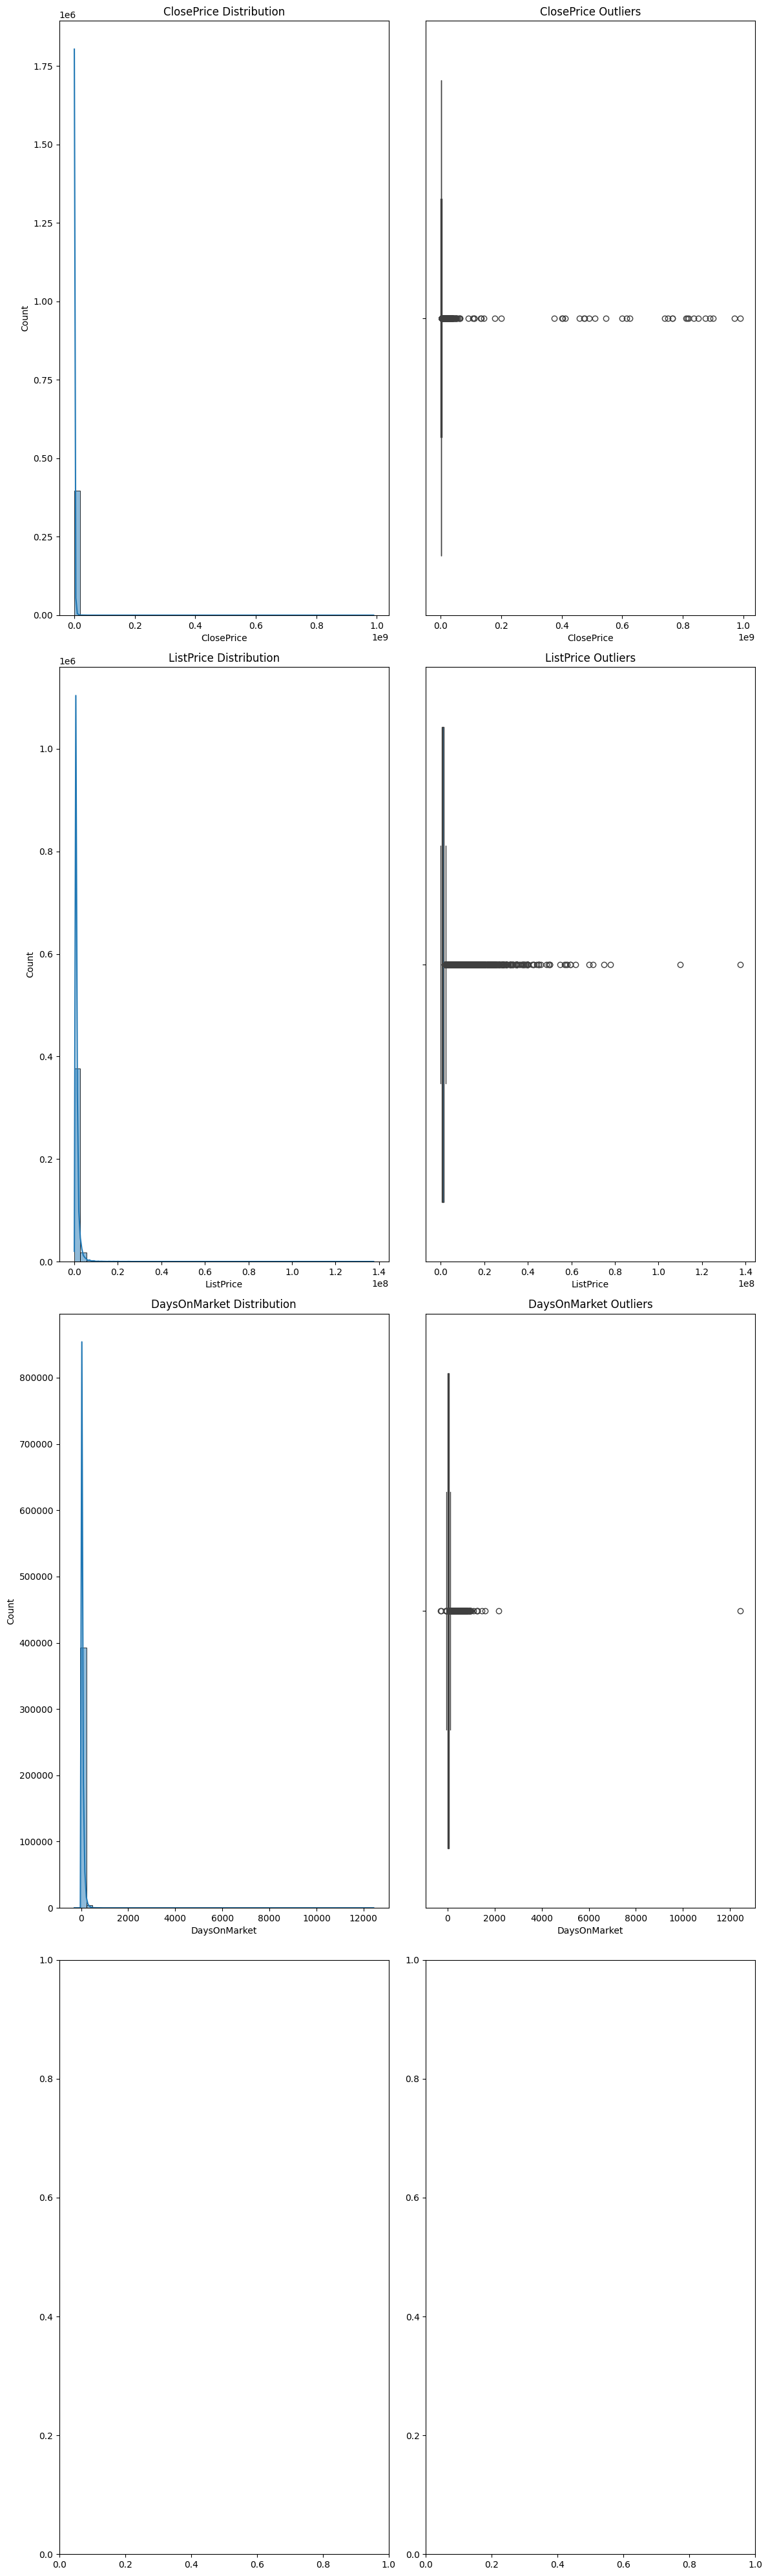

In [11]:
# Graphs
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12,40))

for i, col in enumerate(core_numeric):
    # Histogram
    sns.histplot(sold_df[col],bins=50,kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'{col} Distribution')
    
    # Boxplot
    sns.boxplot(x=sold_df[col], ax=axes[i,1])
    axes[i,1].set_title(f'{col} Outliers')
plt.tight_layout()
plt.show()

### Mortgage Rate Enrichment

In [12]:
import pandas as pd

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"
mortgage = pd.read_csv(url, parse_dates=['observation_date'])

# 2. Rename columns so 'observation_date' becomes 'date' for the pipeline
mortgage.columns = ['date', 'rate_30yr_fixed']

# 3. Resample weekly rates to monthly averages
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = mortgage.groupby('year_month')['rate_30yr_fixed'].mean().reset_index()

# 4. Create a matching year_month key on the Sold dataset using CloseDate
sold_df['year_month'] = pd.to_datetime(sold_df['CloseDate']).dt.to_period('M')

# 5. Merge the dataframes together
sold_with_rates_df = sold_df.merge(mortgage_monthly, on='year_month', how='left')

# 6. Check for missing values and preview the success
print(f"Null mortgage rates: {sold_with_rates_df['rate_30yr_fixed'].isnull().sum()}")
print("\nPreview of the enriched dataset:")
print(sold_with_rates_df[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())

Null mortgage rates: 0

Preview of the enriched dataset:
    CloseDate year_month  ClosePrice  rate_30yr_fixed
0  2024-01-26    2024-01    240000.0           6.6425
1  2024-01-05    2024-01    815000.0           6.6425
2  2024-01-05    2024-01    810000.0           6.6425
3  2024-01-30    2024-01    858000.0           6.6425
4  2024-01-29    2024-01   1890500.0           6.6425


In [13]:
# Export to csv
# sold_with_rates_df.to_csv('CRMLS_Sold_With_Rates.csv', index=False)

## Data Cleaning and Preparation

In [14]:
# Convert data fields to datetime format
date_cols = ['CloseDate','ListingContractDate','PurchaseContractDate','ContractStatusChangeDate']
for col in date_cols:
    if col in sold_with_rates_df.columns:
        sold_with_rates_df[col]= pd.to_datetime(sold_with_rates_df[col])


In [15]:
# Check for duplicates
sold_with_rates_df[sold_with_rates_df.duplicated(subset='ListingKey')]
sold_with_rates_df = sold_with_rates_df.drop_duplicates(subset=['ListingKey'], keep='last') # Keep the most recent property with the listing key

In [16]:
# Drop rows if missing critical value
must_columns = ['ListingKey', 'ClosePrice', 'CloseDate', 'City']
sold_with_rates_df = sold_with_rates_df.dropna(subset=must_columns)

In [17]:
# Fill in missing counts with '0'
zero_fill_cols = ['GarageSpaces', 'ParkingTotal', 'FireplacesTotal']

for col in zero_fill_cols:
    if col in sold_with_rates_df.columns:
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna(0)

# Fill in missing Yes/No features with 'No'
fill_no_cols = ['PoolPrivateYN', 'ViewYN', 'CoolingYN', 'HeatingYN']
for col in fill_no_cols:
    if col in sold_with_rates_df.columns:
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna(False)

# Fill in missing categorical data with "Unknown"
cat_fill_cols = ['ArchitectureStyle', 'Heating', 'Cooling', 'WaterSource']
for col in cat_fill_cols:
    if col in sold_with_rates_df.columns:
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna('Unknown')

# Fill in missing numerical values
num_fill_cols = ['LotSizeArea', 'YearBuilt']
for col in num_fill_cols:
    if col in sold_with_rates_df.columns:
        col_median = sold_with_rates_df[col].median()
        sold_with_rates_df[col] = sold_with_rates_df[col].fillna(col_median)


In [18]:
# Drop missing Living Area
sold_with_rates_df = sold_with_rates_df.dropna(subset='LivingArea')
# Filter out where Living Area is less than 0
sold_with_rates_df = sold_with_rates_df[sold_with_rates_df['LivingArea'] > 0]

In [19]:
# Remove rows with invalid numeric values
sold_with_rates_df = sold_with_rates_df[(sold_with_rates_df['ClosePrice'] > 0) & (sold_with_rates_df['LivingArea'] > 0) & (sold_with_rates_df['DaysOnMarket'] >= 0) & (sold_with_rates_df['BedroomsTotal'] >= 0) & (sold_with_rates_df['BathroomsTotalInteger'] >= 0)]

In [ ]:
# Data consistency checks
sold_with_rates_df['listing_after_close_flag'] = sold_with_rates_df['ListingContractDate'] > sold_with_rates_df['CloseDate']
sold_with_rates_df['purchase_after_close_flag'] = sold_with_rates_df['PurchaseContractDate'] > sold_with_rates_df['CloseDate']
sold_with_rates_df['negative_timeline_flag'] = sold_with_rates_df['DaysOnMarket'] < 0


In [21]:
# Geographic Data Checks
print(f"Number of rows before cleaning {sold_with_rates_df.shape[0]}")

sold_with_rates_df['missing_coords'] = sold_with_rates_df['Latitude'].isnull() | sold_with_rates_df['Longitude'].isnull()
sold_with_rates_df['sentinel_coords'] = (sold_with_rates_df['Latitude'] == 0) | (sold_with_rates_df['Longitude'] == 0)
sold_with_rates_df['cal_coords'] = sold_with_rates_df['Longitude'] > 0
sold_with_rates_df['PostalCode'] = sold_with_rates_df['PostalCode'].astype(str)
sold_with_rates_df['is_california'] = (sold_with_rates_df['StateOrProvince'].isin(['CA', 'California'])) | (sold_with_rates_df['PostalCode'].str.startswith('9'))



Number of rows before cleaning 396487


In [22]:
sold_with_rates_df = sold_with_rates_df[
    (sold_with_rates_df['listing_after_close_flag'] == False) &
    (sold_with_rates_df['purchase_after_close_flag'] == False) &
    (sold_with_rates_df['negative_timeline_flag'] == False) &
    (sold_with_rates_df['missing_coords'] == False) &
    (sold_with_rates_df['sentinel_coords'] == False) &
    (sold_with_rates_df['cal_coords'] == False) & 
    (sold_with_rates_df['is_california'] == True)
]
# Verify row numbers
print(f'Number of rows after cleaning: {sold_with_rates_df.shape[0]}')

Number of rows after cleaning: 380232


In [23]:
# Export to csv
# sold_with_rates_df.to_csv('CRMLS_Sold_With_Rates_Cleaned.csv', index=False)

## Feature Engineering and Market Metrics

In [24]:
sold_with_rates_df['PriceRatio'] = sold_with_rates_df['ClosePrice'] / sold_with_rates_df['OriginalListPrice'] # Measures negotiation strength
sold_with_rates_df['PricePerSqFt'] = sold_with_rates_df['ClosePrice'] / sold_with_rates_df['LivingArea'] # Normalizes price across sizes
sold_with_rates_df['Year'] = sold_with_rates_df['CloseDate'].dt.year # Enable time-series analysis
sold_with_rates_df['Month'] = sold_with_rates_df['CloseDate'].dt.month # Enable time-series analysis
sold_with_rates_df['YrMo'] = sold_with_rates_df['CloseDate'].dt.to_period('M').astype(str) # Enable time-series analysis
sold_with_rates_df['CloseToOriginalListRatio'] = sold_with_rates_df['ClosePrice'] / sold_with_rates_df['OriginalListPrice'] # Captures full price reduction history
sold_with_rates_df['ListingToContractDays'] = sold_with_rates_df['PurchaseContractDate'] - sold_with_rates_df['ListingContractDate'] # Measures time from listing to accepted offer
sold_with_rates_df['ContractToCloseDays'] = sold_with_rates_df['CloseDate'] - sold_with_rates_df['PurchaseContractDate'] # Escrow and closing period duration

columns = ['PriceRatio', 'PricePerSqFt','Year', 'Month','YrMo','CloseToOriginalListRatio','ListingToContractDays','ContractToCloseDays']
sold_with_rates_df[columns].head()


,PriceRatio,PricePerSqFt,Year,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays
4,1.000000,591.891046,2024,1,2024-01,1.000000,0 days,0 days
5,1.000000,562.098501,2024,1,2024-01,1.000000,0 days,48 days
8,0.958065,927.545284,2024,1,2024-01,0.958065,1 days,21 days
9,1.131131,529.026217,2024,1,2024-01,1.131131,1 days,17 days
10,1.009524,552.947314,2024,1,2024-01,1.009524,34 days,6 days


In [25]:
# Segmented summary table by 'PropertySubType'
residential_analysis = sold_with_rates_df.groupby('PropertySubType').agg({
    'ClosePrice': 'median',
    'PricePerSqFt': 'median',
    'DaysOnMarket': 'mean',
    'ListingKey': 'count'
}).reset_index()

# Segmented summary table for CountyOrParish & MLSAreaMajor
area_analysis = sold_with_rates_df.groupby(['CountyOrParish', 'MLSAreaMajor']).agg({
    'ClosePrice': 'median',
    'PricePerSqFt': 'median',
    'DaysOnMarket': 'mean',
    'ListingKey': 'count'
}).reset_index()

# Segmented summary table for ListOfficeName & BuyerOfficeName
office_analysis = sold_with_rates_df.groupby(['ListOfficeName', 'BuyerOfficeName']).agg({
    'ClosePrice': 'median',
    'PricePerSqFt': 'median',
    'DaysOnMarket': 'mean',
    'ListingKey': 'count'
}).reset_index()
print(f'Property Type\n{'-' * 20} \n {residential_analysis.head()}\n')
print(f'Area Analysis\n{'-' * 20} \n{area_analysis.head()}\n')
print(f'Office Analysis\n{'-' * 20} \n + {office_analysis.head()}\n')



Property Type
-------------------- 
   PropertySubType  ClosePrice  PricePerSqFt  DaysOnMarket  ListingKey
0        BoatSlip    182500.0   1750.000000     47.795455          44
1           Cabin    241250.0    287.940606     79.306667         450
2     CoOwnership    439999.0    419.047619     40.266667          15
3     Condominium    625000.0    561.344538     42.172876       62461
4   DeededParking    577500.0    348.407995     26.000000           4

Area Analysis
-------------------- 
  CountyOrParish       MLSAreaMajor  ClosePrice  PricePerSqFt  DaysOnMarket  \
0        Alameda  699 - Not Defined   1140888.0    722.689076     26.981932   
1        Alameda    BERK - Berkeley    782999.0    609.097918     27.666667   
2         Amador  699 - Not Defined    332500.0    153.033794     91.500000   
3          Butte  699 - Not Defined    400000.0    274.012964     58.122449   
4          Butte    PARA - Paradise    375000.0    269.032258     71.890909   

   ListingKey  
0        1439  

In [26]:
# Export to csv
# sold_with_rates_df.to_csv('CRMLS_Sold_With_Rates_Engineered', index=False)

## Outlier Detection and Data Quality

In [ ]:
def get_lower_and_upper(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

close_price_lower, close_price_upper = get_lower_and_upper(sold_with_rates_df, 'ClosePrice')
living_area_lower, living_area_upper = get_lower_and_upper(sold_with_rates_df, 'LivingArea')
days_lower, days_upper = get_lower_and_upper(sold_with_rates_df, 'DaysOnMarket')

# Step 1: Flag outliers on the ORIGINAL df (don't delete yet)
sold_with_rates_df['closeprice_outlier_flag'] = ~sold_with_rates_df['ClosePrice'].between(close_price_lower, close_price_upper)
sold_with_rates_df['livingarea_outlier_flag'] = ~sold_with_rates_df['LivingArea'].between(living_area_lower, living_area_upper)
sold_with_rates_df['dom_outlier_flag'] = ~sold_with_rates_df['DaysOnMarket'].between(days_lower, days_upper)

# Step 2: Create the clean filtered dataset
sold_rates_filtered_df = sold_with_rates_df[
    (sold_with_rates_df['closeprice_outlier_flag'] == False) &
    (sold_with_rates_df['livingarea_outlier_flag'] == False) &
    (sold_with_rates_df['dom_outlier_flag'] == False)
]

# Step 3: Compare before vs. after
print(f"Full dataset:     {len(sold_with_rates_df):,} rows")
print(f"Filtered dataset: {len(sold_rates_filtered_df):,} rows")
print(f"Removed:          {len(sold_with_rates_df) - len(sold_rates_filtered_df):,} rows\n")

print("Median values BEFORE filtering:")
print(sold_with_rates_df[['ClosePrice','LivingArea','DaysOnMarket']].median())
print("\nMedian values AFTER filtering:")
print(sold_rates_filtered_df[['ClosePrice','LivingArea','DaysOnMarket']].median())
# Step 4: Save both
#sold_with_rates_df.to_csv('CRMLS_Sold_Flagged.csv', index=False)       # full dataset with flags
# sold_rates_filtered_df.to_csv('Final_Sold.csv', index=False)

## Export to CSV for Tableau

In [29]:
sold_with_rates_df.to_csv('Final_Sold.csv', index=False)